# TP2 PROCESAMIENTO DEL HABLA

**David Finocchio**


* Resolver las consignas comentando el código fuente, indicando desde dónde fue extraido o generado.

* Explicar y justificar cada paso realizado.

* Publique enlace público a su notebook en google colab y también enlace a su repositorio github de la materia.


### Entrega de los ejercicios

1. Crea un repositorio GitHub público dedicado a esta materia.
2. Sube tus notebooks de resolución para cada desafío allí.
3. Por cada desafío utilizaremos un sólo notebook.
4. Debes entregar tu TP en el foro correspondiente, siguiendo las instrucciones que allí indica.




## EJERCICIO CONSIGNA

* Cree una nube de palabras de un texto en español.

* Dicho texto puede ser descargado de Internet (webscrapping) o extraído del dataset de alguna librería.

* Puede usar cualquier libreria o herramienta para obtener el texto de su interés.

* En este notebook explica el paso a paso del proceso.



## 1- Webscrapping

Extrae un texto de Internet de una sóla página web usando alguna de las técnicas de webscrapping vistas en clase. Busca el discurso de alguna persona quien te inspire o haya dado una charla motivadora.

No puedes repetir ni usar ni el mismo texto ni la misma web que otra persona quien ya entregó en el foro.

Abajo añade los bloques de código y texto necesarios. Explica paso a paso como descargaste el texto de tu interés.


In [ ]:
! pip install requests beautifulsoup4 html5lib nltk

In [ ]:
import requests
from bs4 import BeautifulSoup

In [ ]:
import requests
from bs4 import BeautifulSoup

url = "https://abe.cl/documento-jobs.html"

try:
    respuesta = requests.get(url, timeout=10)
    respuesta.raise_for_status()
    sopa = BeautifulSoup(respuesta.text, "html5lib")

    # Unificamos la búsqueda: intenta h1, si no h2, si no None
    header = sopa.find(["h1", "h2"])

    if header:
        print(f"{header.name.upper()}: {header.get_text(strip=True)}")
    else:
        print("No se encontraron encabezados H1 o H2.")

    # Extraer todo el texto limpio en una sola variable
    texto_final = sopa.get_text(separator=" ", strip=True)
    print("\nVista previa del contenido:", texto_final[:200], "...")

except Exception as e:
    print(f"Error: {e}")

H2: Discurso de Steve Jobs en la Universidad de Stanford.

Vista previa del contenido: Documento: Discurso de Steve Jobs en la Universidad de Stanford Discurso de Steve Jobs en la Universidad de Stanford. Publicado inicialmente en el sitio Mercadeo Global de Álvaro Mendoza,
	  este disc ...


## 2- Preprocesamiento

### 2.1 Muestra las stop words que tenga tu texto.

In [ ]:
import re
from collections import Counter
from nltk.corpus import stopwords

# 1. Preparación de stopwords
stop_words_es = set(stopwords.words("spanish"))

# 2. Tokenización y filtrado en un solo paso
# Extraemos palabras directamente en minúsculas y filtramos solo las stopwords
tokens = re.findall(r"\b[\wáéíóúñü]+\b", sopa.get_text().lower())
encontradas = sorted({t for t in tokens if t in stop_words_es})

# 3. Resultados
print(f"Stopwords únicas: {len(encontradas)}")
print("Muestra:", encontradas[:50])


Stopwords únicas: 123
Muestra: ['a', 'al', 'algo', 'algunas', 'algunos', 'antes', 'como', 'con', 'cuando', 'de', 'del', 'desde', 'durante', 'e', 'el', 'ella', 'ellos', 'en', 'entre', 'era', 'eran', 'es', 'esa', 'ese', 'eso', 'esta', 'estaba', 'estaban', 'estado', 'estar', 'este', 'esto', 'estoy', 'estábamos', 'estás', 'esté', 'fue', 'fuera', 'fueron', 'fuese', 'fui', 'ha', 'habiendo', 'habría', 'había', 'habíamos', 'habían', 'han', 'has', 'hasta']


### 2.2 Quita las stop-words, caracteres extraños del texto. Utiliza el texto restante para crear una nube de palabras. Usa la biblioteca worldcloud de python.

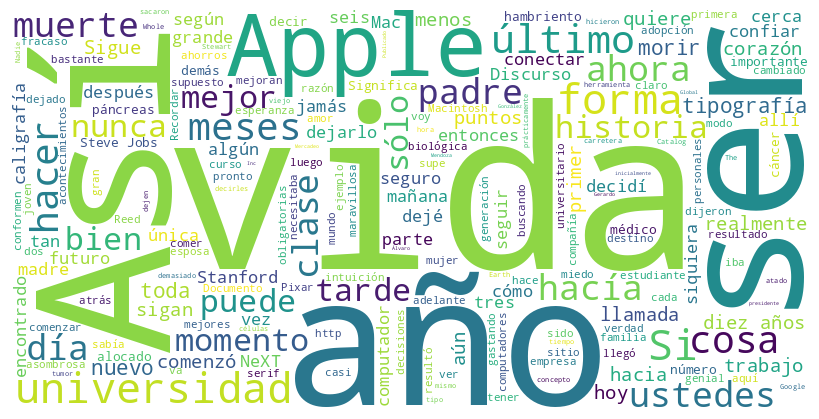

In [ ]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# Texto de ejemplo
text = sopa.get_text()

# Definir stopwords en español
stopwords_es = stop_words_es

# Crear un objeto WordCloud con stopwords en español
wordcloud = WordCloud(width=800, height=400, background_color="white", stopwords=stopwords_es).generate(text)

# Mostramos la imagen generada
plt.figure(figsize=(8, 8), facecolor=None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()

### 2.3 Usando el texto que conseguiste en el punto 1).



#### 2.3.1 Limpia y preprocesa el texto, descomponelo en oraciones, arma una matriz documento-vocabulario.


In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
import nltk

# 1. Preparación de datos (usando las stopwords de NLTK ya definidas)
oraciones = nltk.sent_tokenize(sopa.get_text())

# 2. Vectorización optimizada
# token_pattern elimina números al pedir solo palabras con letras (\b[a-zA-Z...])
vectorizador = CountVectorizer(
    stop_words=list(stop_words_es),
    token_pattern=r"\b[a-záéíóúñü]{2,}\b"
)

matriz_dtm = vectorizador.fit_transform(oraciones)
vocabulario = vectorizador.get_feature_names_out()

# 3. Creación del DataFrame y visualización
df_matriz = pd.DataFrame(matriz_dtm.toarray(), columns=vocabulario)

print(f"Vocabulario detectado: {len(vocabulario)} palabras.")
display(df_matriz.head())

Vocabulario detectado: 720 palabras.


,abogado,abrirse,aconsejó,acontecimientos,actual,actuar,adelante,adiós,adopción,adoptado,...,álvaro,ápice,época,éxito,índice,última,último,últimos,única,útil
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0



#### 2.3.2 Determina la longitud de tu vocabulario.

In [ ]:
print(f"La longitud del vocabulario es: {len(vocabulario)}")

La longitud del vocabulario es: 720



#### 2.3.3. Aplica TF-IDF a tu matriz documento-vocabulario

In [ ]:
from sklearn.feature_extraction.text import TfidfTransformer

# 1. Inicializar el transformador TF-IDF
tfidf_converter = TfidfTransformer(smooth_idf=True, use_idf=True)

# 2. Aplicarlo a la matriz DTM
matriz_tfidf = tfidf_converter.fit_transform(matriz_dtm)

# 3. Convertir a DataFrame para una lectura amigable
df_tfidf = pd.DataFrame(
    matriz_tfidf.toarray(),
    columns=vocabulario
)

print("Matriz TF-IDF generada con éxito.")
print(f"Dimensiones: {df_tfidf.shape}")

# Mostrar las palabras con mayor peso en la primera oración
print("\nPalabras con mayor peso en la oración 0:")
print(df_tfidf.iloc[0].sort_values(ascending=False).head(10))

display(df_tfidf.head())

Matriz TF-IDF generada con éxito.
Dimensiones: (146, 720)

Palabras con mayor peso en la oración 0:
discurso       0.452011
steve          0.452011
stanford       0.452011
jobs           0.452011
universidad    0.350497
documento      0.244738
notorio        0.000000
nuevo          0.000000
nunca          0.000000
número         0.000000
Name: 0, dtype: float64


,abogado,abrirse,aconsejó,acontecimientos,actual,actuar,adelante,adiós,adopción,adoptado,...,álvaro,ápice,época,éxito,índice,última,último,últimos,única,útil
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.195589,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Explica el formato de tu matriz resultante: documentos, vocabulario, tamaño. Brinda tus conclusiones.

La matriz resultante fue de 146x720, con 720 palabras distintas y 146 oraciones que fueron utilizadas como documentos

# Conclusiones

Agregue aquí sus conclusiones sobre este trabajo práctico. Puede ser también parte del texto que posteará en el foro.

El texto que elegi fue el discurso de Steve Jobs en Stanford en 2005. El trabajo fue una continuación de el TP1, donde se profundizo aún más en las técnicas de preprocesamiento y sobre todo las matrices, fue una forma de pasar de la teoría a la práctica y empezar a "meter mano" en el código. La parte más difícil fue solucionar los errores que se presentaban al procesar el texto, ya que tuve que variar el código para poder extraerlo correctamente, así como adaptar los posteriores pasos a lo que necesitaba.